In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
df = pd.read_csv("/kaggle/input/datasets/tanishkagolya/zomato/zomato.csv",encoding='latin')

Because `encoding` tells Python **how to convert file bytes into readable text characters**.

in this  CSV file is stored internally as bytes like:


101010101...


To understand these bytes, Python needs a character encoding rule.

Different encodings = different rules.

Examples:

* UTF-8
* latin1
* ASCII
* cp1252

By default:


pd.read_csv()


uses:

encoding='utf-8'


But my file was probably saved using **latin1** encoding, not UTF-8.

So when Python tried UTF-8:

0xed


it found a byte that is invalid in UTF-8 format → error came.

When you write:


encoding='latin1'

you are basically saying:

> "Read this file using latin1 character rules."

Then pandas can correctly decode all characters.



Simple real-life analogy 

Imagine:

* File bytes = secret language symbols
* Encoding = dictionary/rules to read them

Wrong dictionary → gibberish/error
Correct dictionary → proper text


Why `latin1` works so often?

Because:

* `latin1` can decode almost every byte value from 0–255
* It is more tolerant than UTF-8
* Many old CSV/Excel exports use it

---

Example:


df = pd.read_csv("file.csv", encoding='latin1')

means:

> "Open this CSV and interpret characters using latin1 encoding."


In [4]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [5]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

object in pandas dataframe means strings,it can be a categorical or text .

In [7]:
df.describe()
#() = execute/call function
#without () = only refer to function object

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


#in data anaysis the things all we do -
missing value
explores about numeric variable
explores about categorical variables
finding relatioonship between features


In [8]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [9]:
[features for features in df.columns if df[features].isnull().sum()>0]

['Cuisines']

This is a list comprehension used to find columns that contain missing values (NaN)

In [10]:
cols = []

for features in df.columns:
    if df[features].isnull().sum() > 0:
        cols.append(features)

print(cols)

['Cuisines']


<Axes: >

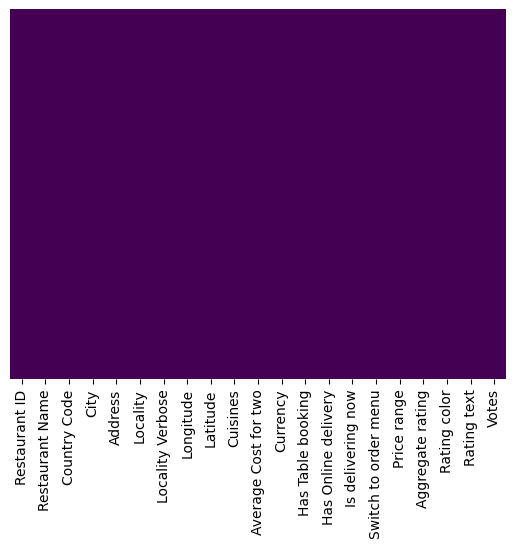

In [11]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')
#This line creates a heatmap of missing values using Seaborn.

This line creates a **heatmap of missing values** using Seaborn.

Code:


sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
```




 Step 1 → df.isnull()

Checks every value in dataframe.

Output becomes:

True   -> value missing
False  -> value present
```

Example:

| Name  | Age |
| ----- | --- |
| Ram   | 20  |
| Shyam | NaN |

After:

df.isnull()


Output:

| Name  | Age   |
| ----- | ----- |
| False | False |
| False | True  |

---

# Step 2 → `sns.heatmap()`

Heatmap converts data into colors.

Here:

* `True` = one color
* `False` = another color

So you can visually detect missing values quickly.

---
 Step 3 → `yticklabels=False`

Removes row numbers from left side.

Without this:

0
1
2
3

will appear.

Used to make plot cleaner.


Step 4 → `cbar=False`

Removes color bar from side.

Color bar means:

yellow = True
purple = False
```

Since we already know it’s null vs non-null, color bar is unnecessary.


 Step 5 → `cmap='viridis'`

Chooses color theme.

`viridis` gives purple-yellow shades.

Other examples:

`
cmap='coolwarm'
cmap='Blues'
cmap='plasma'


# Final Meaning

sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

means:
 “Show me visually where missing values are present in dataframe.”

Usually:

* dark color = value exists
* bright color = missing value

So if one column has many bright lines → lots of missing data there 


In [12]:
df.shape

(9551, 21)

In [13]:
df_country = pd.read_csv("/kaggle/input/datasets/koki25ando/country-code/country_code.csv")

In [14]:
df_country

,Unnamed: 0,Country_name,code_2digit,code_3digit
0,2,Afghanistan,AF,AFG
1,3,Aland Islands,AX,ALA
2,4,Albania,AL,ALB
3,5,Algeria,DZ,DZA
4,6,American Samoa,AS,ASM
...,...,...,...,...
242,244,Wallis and Futuna Islands,WF,WLF
243,245,Western Sahara,EH,ESH
244,246,Yemen,YE,YEM
245,247,Zambia,ZM,ZMB


In [15]:
# remove unnamed columns
df_country.drop(
    df_country.columns[df_country.columns.str.contains('^Unnamed')],
    axis=1,
    inplace=True
)

# create Country Code column
df_country['Country Code'] = (
    df_country['code_2digit'] + "-" + df_country['code_3digit']
)

# convert categorical country codes into numerical values
df_country['Country Code'] = pd.factorize(
    df_country['Country Code']
)[0]

# remove old code columns
df_country.drop(
    ['code_2digit', 'code_3digit'],
    axis=1,
    inplace=True
)

# keep only required columns
df_country = df_country[['Country_name', 'Country Code']]

# display
df_country.head()

,Country_name,Country Code
0,Afghanistan,0
1,Aland Islands,1
2,Albania,2
3,Algeria,3
4,American Samoa,4


In [16]:
final_df = pd.merge(df,df_country,on='Country Code',how='inner')

In [17]:
final_df.head(4)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Country_name
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Yes,No,No,No,3,4.8,Dark Green,Excellent,314,Norfolk Island
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Yes,No,No,No,3,4.5,Dark Green,Excellent,591,Norfolk Island
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Yes,No,No,No,4,4.4,Green,Very Good,270,Norfolk Island
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,No,No,No,No,4,4.9,Dark Green,Excellent,365,Norfolk Island


In [18]:
final_df.dtypes

Restaurant ID             int64
Restaurant Name          object
Country Code              int64
City                     object
Address                  object
Locality                 object
Locality Verbose         object
Longitude               float64
Latitude                float64
Cuisines                 object
Average Cost for two      int64
Currency                 object
Has Table booking        object
Has Online delivery      object
Is delivering now        object
Switch to order menu     object
Price range               int64
Aggregate rating        float64
Rating color             object
Rating text              object
Votes                     int64
Country_name             object
dtype: object

In [19]:
final_df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'Country_name'],
      dtype='object')

In [20]:
city_name = final_df.City.value_counts().index

In [21]:
city_name

Index(['New Delhi', 'Gurgaon', 'Noida', 'Faridabad', 'Ghaziabad',
       'Bhubaneshwar', 'Lucknow', 'Ahmedabad', 'Amritsar', 'Guwahati',
       ...
       'Forrest', 'East Ballina', 'Huskisson', 'Inverloch', 'Lakeview',
       'Lakes Entrance', 'Mohali', 'Panchkula', 'Bandung', 'Randburg'],
      dtype='object', name='City', length=141)

In [22]:
city_value = final_df.City.value_counts().values

([<matplotlib.patches.Wedge at 0x7a066dd1bd10>,
 [Text(-0.2501619413267165, 1.0711764575043874, 'New Delhi'),
  Text(-0.745121858820895, -0.8091930644211518, 'Gurgaon'),
  Text(-0.02333574341226038, -1.0997524462711585, 'Noida'),
  Text(0.44510624964796647, -1.0059226742271608, 'Faridabad'),
  Text(0.5344701079997939, -0.9614269101989442, 'Ghaziabad'),
  Text(0.5489552642716152, -0.9532303592670982, 'Bhubaneshwar'),
  Text(0.5620712685852676, -0.945555862459193, 'Lucknow'),
  Text(0.5750800020755771, -0.9377009071195113, 'Ahmedabad'),
  Text(0.5879789820368265, -0.9296669923595962, 'Amritsar'),
  Text(0.6007653073253033, -0.9214559379125701, 'Guwahati'),
  Text(0.613137406926929, -0.913270233954289, 'Rio de Janeiro'),
  Text(0.6250997896337347, -0.9051244406156873, 'Brasí_lia'),
  Text(0.6369543944046185, -0.8968216653541805, 'Albany'),
  Text(0.6486983099574557, -0.8883639471851281, 'Doha'),
  Text(0.6603303545009076, -0.8797521372095131, 'Cape Town'),
  Text(0.6718480867292544, -0.87

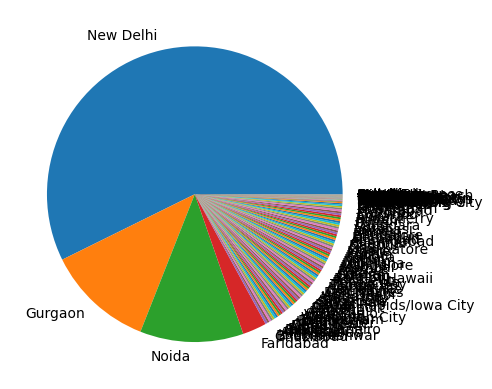

In [23]:
#pie chart 
plt.pie(city_value,labels=city_name)

([<matplotlib.patches.Wedge at 0x7a066d67cb90>,
 [Text(-0.6836226235765238, 0.8617772963674262, 'New Delhi'),
  Text(0.24897521967717012, -1.07145291076496, 'Gurgaon'),
  Text(0.9941444825293274, -0.47082560238000676, 'Noida')])

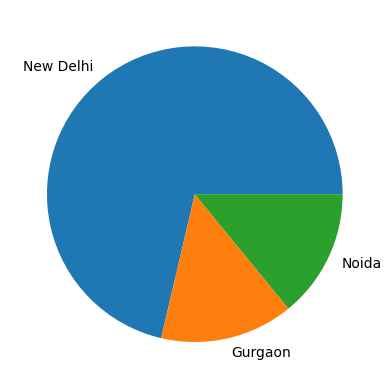

In [24]:
#top 3 city zomato use
plt.pie(city_value[:3],labels=city_name[:3])

([<matplotlib.patches.Wedge at 0x7a066d69aa80>,
 [Text(-0.6836226235765238, 0.8617772963674262, 'New Delhi'),
  Text(0.24897521967717012, -1.07145291076496, 'Gurgaon'),
  Text(0.9941444825293274, -0.47082560238000676, 'Noida')],
 [Text(-0.3728850674053766, 0.4700603434731415, '71.35%'),
  Text(0.13580466527845642, -0.5844288604172508, '14.57%'),
  Text(0.5422606268341785, -0.2568139649345491, '14.08%')])

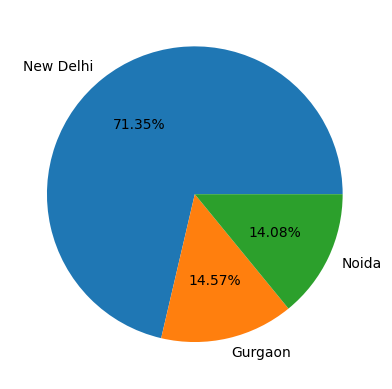

In [25]:
#now i want to see in term of percentage - use autopact
#top 3 city zomato use
plt.pie(city_value[:3],labels=city_name[:3],autopct='%1.2f%%')

Observation:Zomato maximum records or transaction are from New Delhi After that Gurgaon and then Noida

In [26]:
final_df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'Country_name'],
      dtype='object')

In [27]:
final_df.groupby(['Aggregate rating','Rating color', 'Rating text']).size()

Aggregate rating  Rating color  Rating text
0.0               White         Not rated      2148
1.8               Red           Poor              1
1.9               Red           Poor              2
2.0               Red           Poor              7
2.1               Red           Poor             15
2.2               Red           Poor             27
2.3               Red           Poor             47
2.4               Red           Poor             87
2.5               Orange        Average         110
2.6               Orange        Average         191
2.7               Orange        Average         250
2.8               Orange        Average         315
2.9               Orange        Average         381
3.0               Orange        Average         468
3.1               Orange        Average         519
3.2               Orange        Average         522
3.3               Orange        Average         483
3.4               Orange        Average         498
3.5               Ye

In [28]:
ratings = final_df.groupby(['Aggregate rating','Rating color', 'Rating text']).size().reset_index().rename(columns={0:'Rating Count'})

Observation : dark green color indicate excellent rating 4.5 to 4.9 highest..
              green - very good
              yellow - good
              orange - average
              red - poor
              white - no rated


When Rating is between 4.5 to 4.9---> Excellent

When Rating are between 4.0 to 3.4--->very good

when Rating is between 3.5 to 3.9----> good

when Rating is between 3.0 to 3.4----> average

when Rating is between 2.5 to 2.9----> average

when Rating is between 2.0 to 2.4----> Poor
              

In [29]:
final_df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'Country_name'],
      dtype='object')

In [30]:
ratings.head()

,Aggregate rating,Rating color,Rating text,Rating Count
0,0.0,White,Not rated,2148
1,1.8,Red,Poor,1
2,1.9,Red,Poor,2
3,2.0,Red,Poor,7
4,2.1,Red,Poor,15


<Axes: xlabel='Aggregate rating', ylabel='Rating Count'>

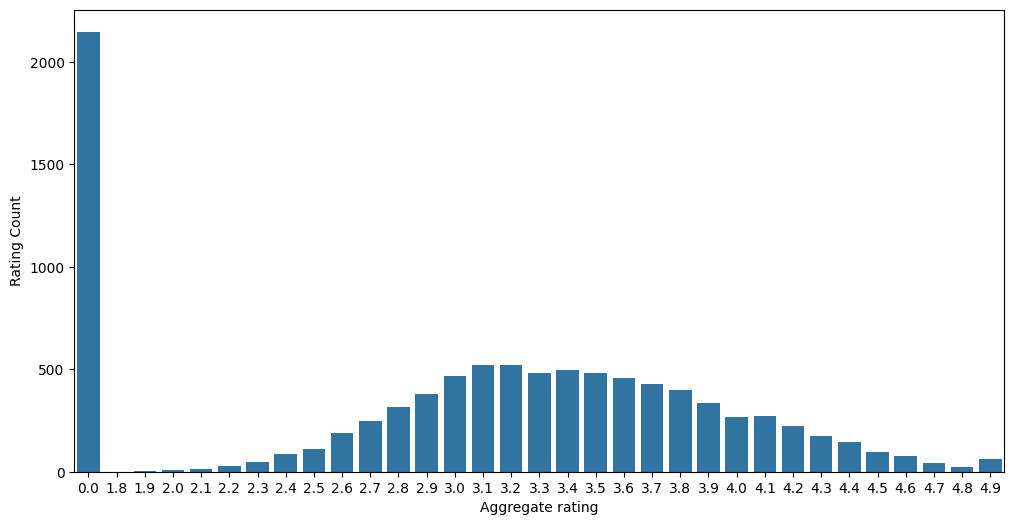

In [31]:
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 6)
sns.barplot(x="Aggregate rating",y="Rating Count",data=ratings)

<Axes: xlabel='Aggregate rating', ylabel='Rating Count'>

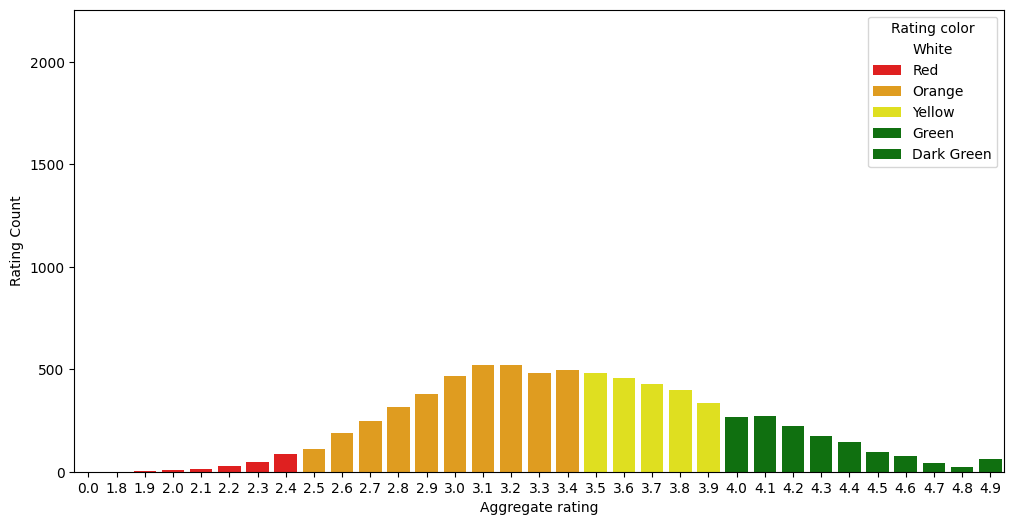

In [32]:
sns.barplot(x="Aggregate rating",y="Rating Count",hue = 'Rating color',data=ratings,palette=['white','red','orange','yellow','green','green'])

observation - not rated - white color count is high ... 
mac no of rating are between 2.5 to 3.4 

/tmp/ipykernel_57/2576527937.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Rating color",data=ratings,palette=['blue','red','orange','yellow','green','green'])


<Axes: xlabel='Rating color', ylabel='count'>

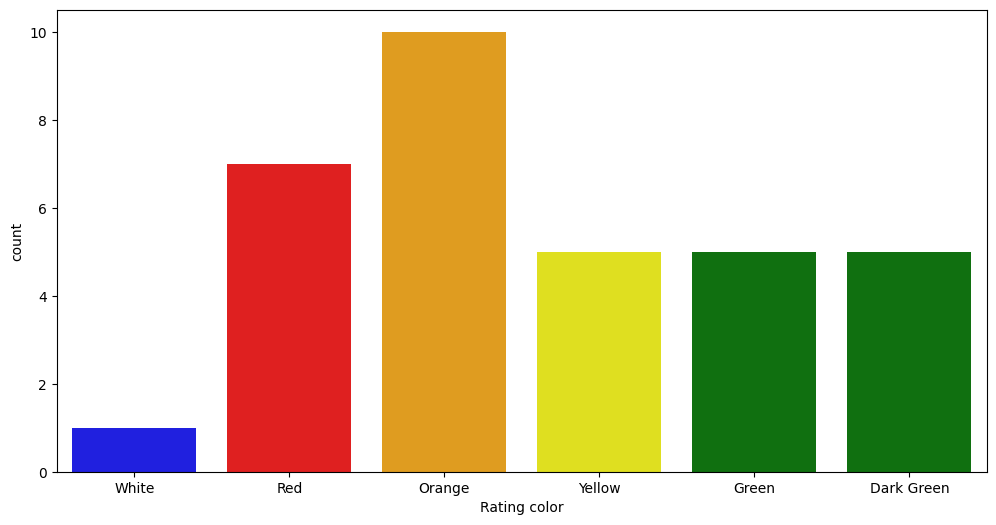

In [33]:
## Count plot
sns.countplot(x="Rating color",data=ratings,palette=['blue','red','orange','yellow','green','green'])

In [34]:
#find country name that give 0 rating 
final_df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'Country_name'],
      dtype='object')

In [35]:
final_df[final_df['Rating color']=='White'].groupby('City').size().reset_index()

,City,0
0,Birmingham,1
1,Brasí_lia,1
2,Davenport,2
3,Faridabad,100
4,Ghaziabad,2
5,Gurgaon,228
6,New Delhi,1425
7,Noida,384
8,Pocatello,1
9,Rio de Janeiro,1


In [36]:
final_df.groupby(['Aggregate rating','City']).size().reset_index().head(5)

,Aggregate rating,City,0
0,0.0,Birmingham,1
1,0.0,Brasí_lia,1
2,0.0,Davenport,2
3,0.0,Faridabad,100
4,0.0,Ghaziabad,2


max number of 0 rating given by faridabad.. around 100 people give 0 rating



In [37]:
final_df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'Country_name'],
      dtype='object')

In [38]:
#find out the which currency use Country_name
final_df[['Country_name','Currency']].groupby(['Country_name','Currency']).size().reset_index()

,Country_name,Currency,0
0,Aland Islands,Indian Rupees(Rs.),8652
1,Austria,Dollar($),24
2,Brazil,Brazilian Real(R$),60
3,Cambodia,Dollar($),4
4,Guinea-Bissau,Indonesian Rupiah(IDR),21
5,Montserrat,NewZealand($),40
6,Norfolk Island,Botswana Pula(P),22
7,Pakistan,Qatari Rial(QR),20
8,Saint Helena,Dollar($),20
9,Saint Vincent and Grenadines,Rand(R),60


In [39]:
#which country do have online delivery 
final_df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'Country_name'],
      dtype='object')

In [40]:
final_df[['Country_name','Has Online delivery']].groupby(['Country_name','Has Online delivery']).size().reset_index()

,Country_name,Has Online delivery,0
0,Aland Islands,No,6229
1,Aland Islands,Yes,2423
2,Austria,No,24
3,Brazil,No,60
4,Cambodia,No,4
5,Guinea-Bissau,No,21
6,Montserrat,No,40
7,Norfolk Island,No,22
8,Pakistan,No,20
9,Saint Helena,No,20


observation : online del available on Syrian Arab Republic (Syria) and Aland Islands	

.size() =

“Count number of rows inside each group

In [41]:

#create a pie chart for Country_name distribution
Country_name = final_df.Country_name.value_counts().index


In [42]:
Country_name

Index(['Aland Islands', 'Tajikistan', 'Taiwan, Republic of China', 'Brazil',
       'Saint Vincent and Grenadines', 'Syrian Arab Republic (Syria)',
       'Montserrat', 'Sudan', 'Austria', 'Norfolk Island', 'Guinea-Bissau',
       'Pakistan', 'Saint Helena', 'San Marino', 'Cambodia'],
      dtype='object', name='Country_name')

In [43]:
Country_name_values=final_df.Country_name.value_counts().values
Country_name_labels=final_df.Country_name.value_counts().index

([<matplotlib.patches.Wedge at 0x7a066d391f70>,
 [Text(-1.082974277862112, 0.1927867046480056, 'Aland Islands'),
  Text(1.0772816964394372, -0.22240536530526556, 'Tajikistan'),
  Text(1.0995865232164619, -0.030157552300104404, 'Taiwan, Republic of China')],
 [Text(-0.5907132424702428, 0.10515638435345759, '94.39%'),
  Text(0.5876081980578747, -0.12131201743923574, '4.73%'),
  Text(0.5997744672089791, -0.01644957398187513, '0.87%')])

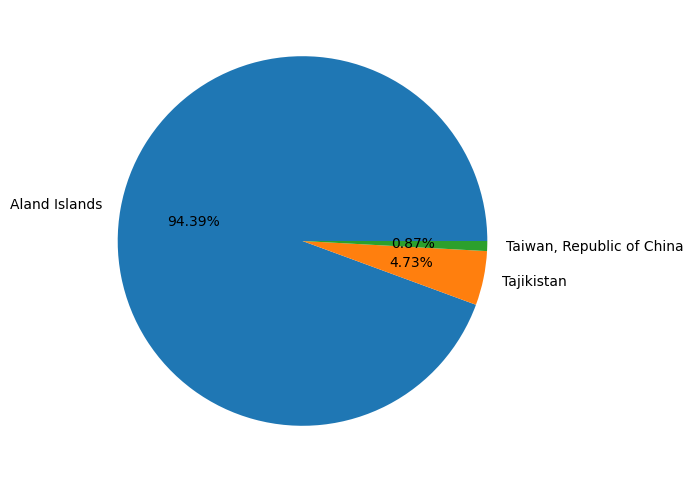

In [44]:
plt.pie(Country_name_values[:3],labels=Country_name_labels[:3],autopct='%1.2f%%')

In [46]:
#find top 10 cusiene
final_df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'Country_name'],
      dtype='object')

In [53]:
final_df['Cuisines'].value_counts().head(10).reset_index()

,Cuisines,count
0,North Indian,936
1,"North Indian, Chinese",511
2,Chinese,354
3,Fast Food,354
4,"North Indian, Mughlai",334
5,Cafe,299
6,Bakery,218
7,"North Indian, Mughlai, Chinese",197
8,"Bakery, Desserts",170
9,Street Food,149


<Axes: xlabel='Cuisines'>

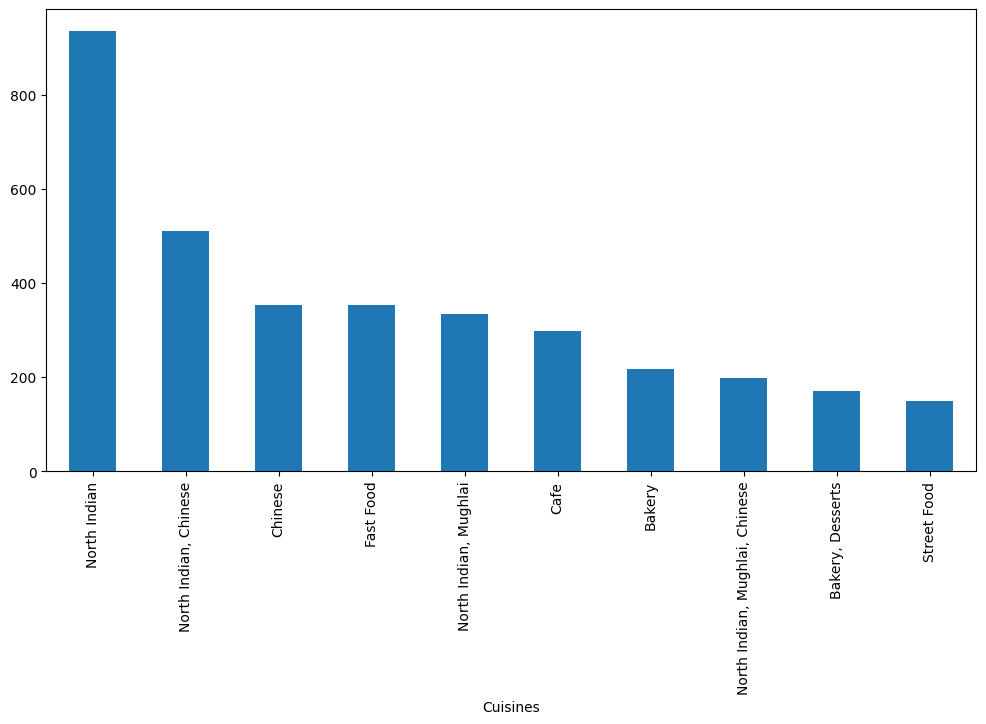

In [54]:
final_df['Cuisines'].value_counts().head(10).plot(kind='bar')